In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc
rc('animation', html='html5')
import os

In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [5]:
path_run = '/data/jvalenti/results/' 
#path_run = '/home/jvalenti/scratch/run_SHEM/results/' 

#path_run = '/home/jvalenti/projects/rrg-allen/SalishSea/nowcast-green.202111/'
#path_run = '/ocean/atall/MOAD/Model/202410b/oxygen/'
day = 1
start = datetime(2025,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'02jan25/SHEM_1h_20250102-20250102_biol_T.nc'

In [6]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [7]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


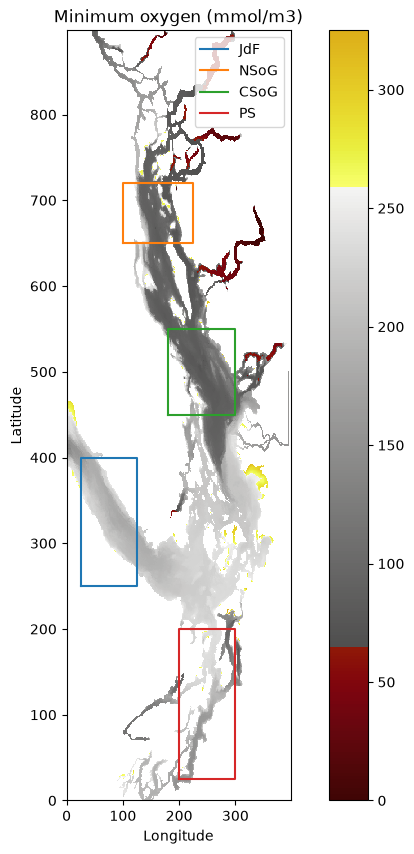

In [8]:
cmap = cmocean.cm.oxy
colorsn=['tab:blue','tab:orange','tab:green','tab:red']
fig, ax = plt.subplots(figsize=(10,10))
ox_0 = Ox[0,:,:,:]*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')
plt.pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colorsn[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [9]:
# cmap = cmocean.cm.matter
# colors=['tab:blue','tab:orange','tab:green','tab:red']
# fig, ax = plt.subplots(figsize=(10,10))
# hbac_t = hbac[0,:,:,:]*mask.tmask[0,0,:,:]
# plt.pcolormesh(hbac_t[0,:,:],cmap=cmap)
# plt.colorbar()
# f = 1.0/np.cos(49*np.pi/180)
# for i,region in enumerate(regions.keys()):
#     mark_region(region,color=colors[i])
# plt.legend()
# plt.gca().set_aspect(f)
# plt.title('Maximum Heterotrophic Bacteria (mmol/m3)')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

In [10]:
def domain_profile(
    hbac,
    mask,
    colors,
    region=None,
    regions=None,
    plot=True,
    daily_mean=False
):
    """Compute volume-weighted mean + std vertical profile optionally for a sub-region."""

    # volume mask
    volume = mask.volume
    vol = volume.where(mask.tmask == 1)

    # region slicing
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        hbac_r = hbac.isel(y=slice(y0, y1), x=slice(x0, x1))
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        hbac_r = hbac
        vol_r = vol

    # daily mean 
    if daily_mean:
        hbac_day = hbac_r.mean(dim="time_counter", skipna=True) 
    else:
        hbac_day = hbac_r
    #mean profile 
    hbac_total = (hbac_day * vol_r).sum(("z", "y", "x"))
    vol_sum = vol_r.sum(("z", "y", "x"))
    hbac_vmean = hbac_total / vol_sum

    # plot
    if plot:
        y = hbac_day.deptht.values.ravel()
        mean = hbac_vmean.values.ravel()
        plt.plot(mean, y, label=region,c=colors[region])
        plt.legend()

    return hbac_vmean

In [11]:
# path_run = '/ocean/atall/MOAD/Model/202410b/oxygen/' 
# day = 0
# Len = 730
# start = datetime(2023,1,1)

# mean_profiles = np.full((2,len(regions.keys()), Len, Ox.deptht.shape[0]),np.nan)

# for day in range(Len):
#     if day ==424:
#         print(start + timedelta(days=day))
#         continue
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='d')) as ds:
#         T = ds.microzooplankton.isel(time_counter=0)
#         S = ds.mesozooplankton.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[0, i, day, :]  = domain_profile(T, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
#             mean_profiles[1, i, day, :]  = domain_profile(S, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_oxy_zoo_regions.npy', mean_profiles)

In [12]:
# #path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
# day = 0
# Len = 730
# start = datetime(2023,1,1)

# mean_profiles = np.full((2,len(regions.keys()), Len, Ox.deptht.shape[0]),np.nan)

# for day in range(Len):
#     if day ==424:
#         print(start + timedelta(days=day))
#         continue
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='grid_T', res='h')) as ds:
#         T = ds.votemper.isel(time_counter=0)
#         S = ds.vosaline.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[0, i, day, :]  = domain_profile(T, mask,colors_reg, plot=False).values.ravel()
#             mean_profiles[1, i, day, :]  = domain_profile(S, mask,colors_reg, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_ST_full.npy', mean_profiles)

In [13]:
def progress_bar(iterable, total=None, length=30):
    total = total or len(iterable)
    for i, item in enumerate(iterable, 1):
        filled = int(length * i / total)
        bar = '█' * filled + '-' * (length - filled)
        print(f'\r|{bar}| {i}/{total}', end='', flush=True)
        yield item
    print()

In [14]:
# path_run = '/data/jvalenti/results/' 
# day = 0
# Len = 365
# start = datetime(2025,1,1)

# mean_profiles = np.full((len(regions.keys()), Len, hbac.deptht.shape[0]),np.nan)

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[i, day, :]  = domain_profile(hbac, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_2025.npy', mean_profiles)

In [15]:
# day = 0
# Len = 365
# start = datetime(2025,1,1)

# mean_profiles = np.full((Len, hbac.deptht.shape[0]),np.nan)

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         mean_profiles[day, :]  = domain_profile(hbac, mask,colors_reg, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_2025.npy', mean_profiles)

In [16]:
# path_run = '/home/jvalenti/scratch/run_SHEM/results/' 
# day = 0
# Len = 365
# start = datetime(2025,1,1)

# mean_profiles = np.full((Len, hbac.deptht.shape[0]),np.nan)

# for day in range(Len):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         mean_profiles[day, :]  = domain_profile(hbac, mask,colors_reg, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_2025.npy', mean_profiles)

In [17]:
# path_run = '/home/jvalenti/scratch/run_SHEM/results/' 
# day = 0
# Len = 365
# start = datetime(2025,1,1)

# mean_profiles = np.full((len(regions.keys()), Len, hbac.deptht.shape[0]),np.nan)

# for day in range(Len):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         hbac = ds.heterotrophic_bacteria.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[i, day, :]  = domain_profile(hbac, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_2025.npy', mean_profiles)

Text(0.5, 1.0, 'Full Domain 2024')

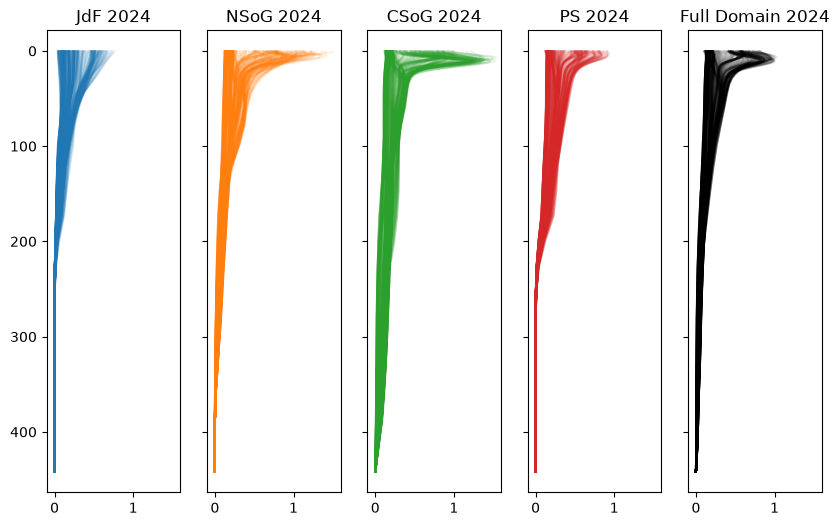

In [18]:
mean_profiles = np.load('profiles_full_2024.npy')
mean_profiles_reg = np.load('profiles_regions_2024.npy')

fig, axs = plt.subplots(1,5,figsize=(10,6),sharey=True)
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,:,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region+' 2024')
    axs[i].set_xlim(-0.1,1.6)
axs[i].invert_yaxis()

axs[4].plot(mean_profiles.T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(-0.1,1.6)
axs[4].set_title('Full Domain 2024')


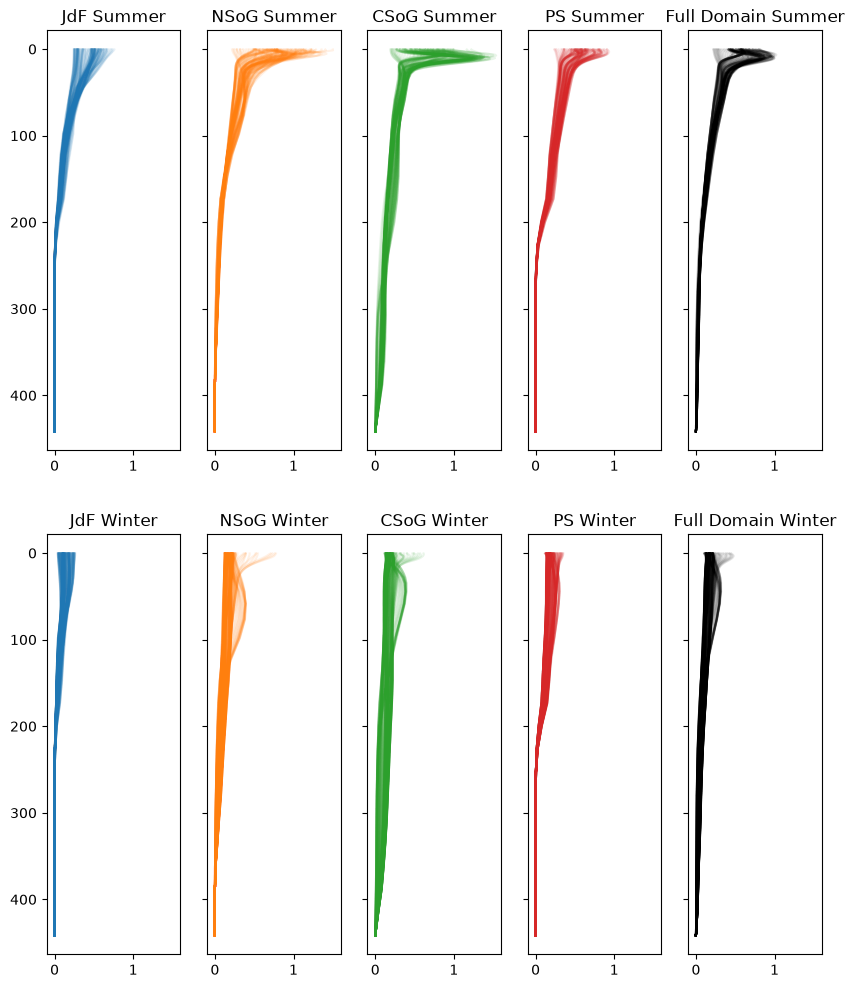

In [19]:
#From beginning of May to end of September
summer = slice(121, 274)

winter = np.ones(365, dtype=bool)
winter[summer] = False

fig, axs = plt.subplots(2,5,figsize=(10,12),sharey=True)
axs = axs.flatten()
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,summer,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region+' Summer')
    axs[i].set_xlim(-0.1,1.6)

axs[4].plot(mean_profiles[summer,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(-0.1,1.6)
axs[4].set_title('Full Domain Summer')

for i,region in enumerate(regions.keys()):
    axs[5+i].plot(mean_profiles_reg[i,winter,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[5+i].set_title(region+' Winter')
    axs[5+i].set_xlim(-0.1,1.6)

axs[9].plot(mean_profiles[winter,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[9].set_xlim(-0.1,1.6)
axs[9].set_title('Full Domain Winter')
axs[9].invert_yaxis()

In [20]:
colors_reg_winter = {'JdF':'#87CEEB','NSoG':"#F7D699",'CSoG':'#90EE90','PS':'#FFC0CB'}
colors_reg={'JdF':'#3054FC','NSoG':'#FFA500','CSoG':'#008000','PS':'#FF0000'}

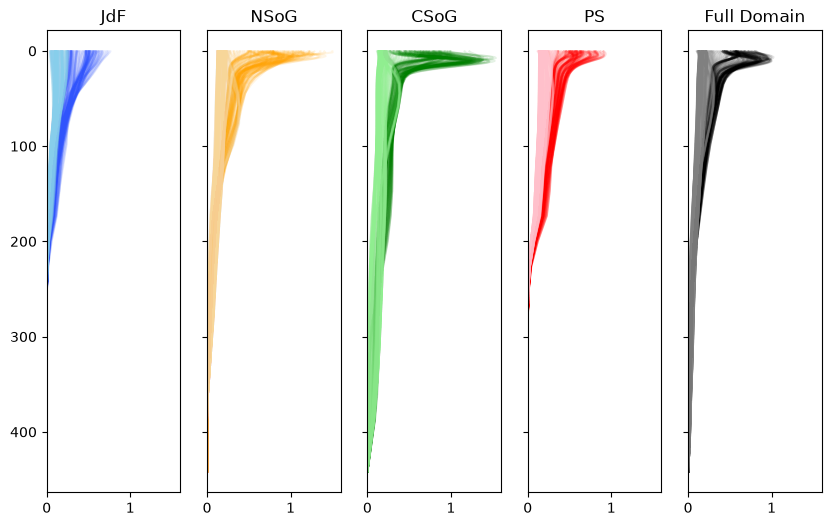

In [21]:
#From beginning of May to end of September
# mean_profiles = np.load('profiles_full_2024.npy')
# mean_profiles_reg = np.load('profiles_regions_2024.npy')

summer = slice(121, 274)

winter = np.ones(365, dtype=bool)
winter[summer] = False

xmax = 4e6/2500000

fig, axs = plt.subplots(1,5,figsize=(10,6),sharey=True)
axs = axs.flatten()
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,summer,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[summer,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')

for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,winter,:].T,hbac.deptht,c=colors_reg_winter[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[winter,:].T,hbac.deptht,c='grey',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')
axs[4].invert_yaxis()
#axs[4].set_ylim(200,-2)

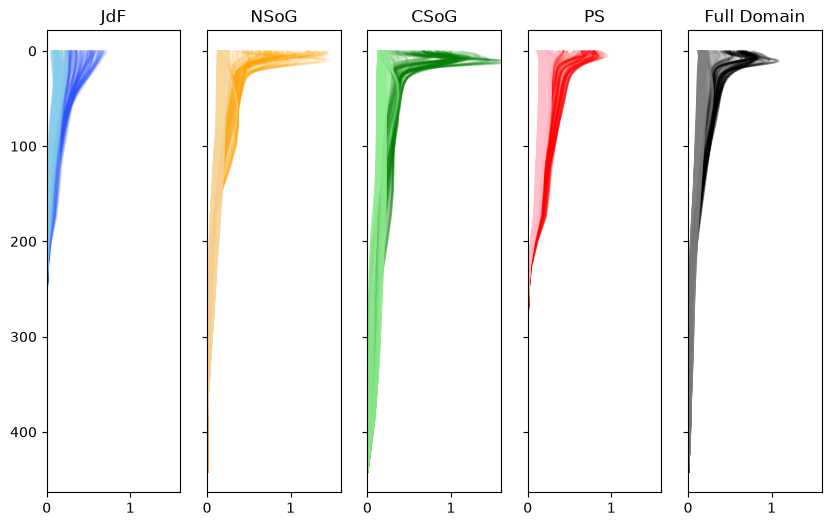

In [22]:
#From beginning of May to end of September
mean_profiles = np.load('profiles_full_2025.npy')
mean_profiles_reg = np.load('profiles_regions_2025.npy')

summer = slice(121, 274)

winter = np.ones(365, dtype=bool)
winter[summer] = False

xmax = 4e6/2500000

fig, axs = plt.subplots(1,5,figsize=(10,6),sharey=True)
axs = axs.flatten()
for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,summer,:].T,hbac.deptht,c=colors_reg[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[summer,:].T,hbac.deptht,c='k',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')

for i,region in enumerate(regions.keys()):
    axs[i].plot(mean_profiles_reg[i,winter,:].T,hbac.deptht,c=colors_reg_winter[region],label=region,alpha=0.1)
    axs[i].set_title(region)
    axs[i].set_xlim(0,xmax)

axs[4].plot(mean_profiles[winter,:].T,hbac.deptht,c='grey',label='full domain',alpha=0.1)
axs[4].set_xlim(0,xmax)
axs[4].set_title('Full Domain')
axs[4].invert_yaxis()
#axs[4].set_ylim(200,-2)

In [23]:
vol = mask.volume.where(mask.tmask == 1).sel(t=0)

In [24]:
mean_profiles_2023 = np.load('profiles_full.npy')
mean_profiles_reg_2023 = np.load('profiles_regions.npy')
mean_profiles = np.load('profiles_full_2024.npy')
mean_profiles_reg = np.load('profiles_regions_2024.npy')
mean_profiles_2025 = np.load('profiles_full_2025.npy')
mean_profiles_reg_2025 = np.load('profiles_regions_2025.npy')


mean_profiles = np.append(mean_profiles_2023,mean_profiles, axis=0)
mean_profiles = np.append(mean_profiles[:424,:],mean_profiles[425:,:], axis=0)
mean_profiles = np.append(mean_profiles,mean_profiles_2025, axis=0)

mean_profiles_reg = np.append(mean_profiles_reg_2023,mean_profiles_reg, axis=1)
mean_profiles_reg = np.append(mean_profiles_reg[:,:424,:],mean_profiles_reg[:,425:,:], axis=1)
mean_profiles_reg = np.append(mean_profiles_reg,mean_profiles_reg_2025, axis=1)

np.save('profiles_full_3year.npy', mean_profiles)
np.save('profiles_regions_3year.npy', mean_profiles_reg)

In [25]:
mean_profiles = np.load('profiles_full_3year.npy')
mean_profiles_reg = np.load('profiles_regions_3year.npy')

Len = mean_profiles.shape[0]

region = 'JdF'
ii = 0
weighted_means = np.full((len(regions.keys())+1,Len), np.nan)

def weighted_mean_concentration(mean_profile,region=None,regions=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        vol_r = vol

    vol_r = vol_r.sum(axis=(1,2))
    weighted_mean = np.average(mean_profile,axis=1,weights=vol_r)
    return weighted_mean

for ii, region in enumerate(regions.keys()):
    weighted_means[ii,:] = weighted_mean_concentration(mean_profiles_reg[ii,:,:], region=region, regions=regions)


weighted_means_full = weighted_mean_concentration(mean_profiles)

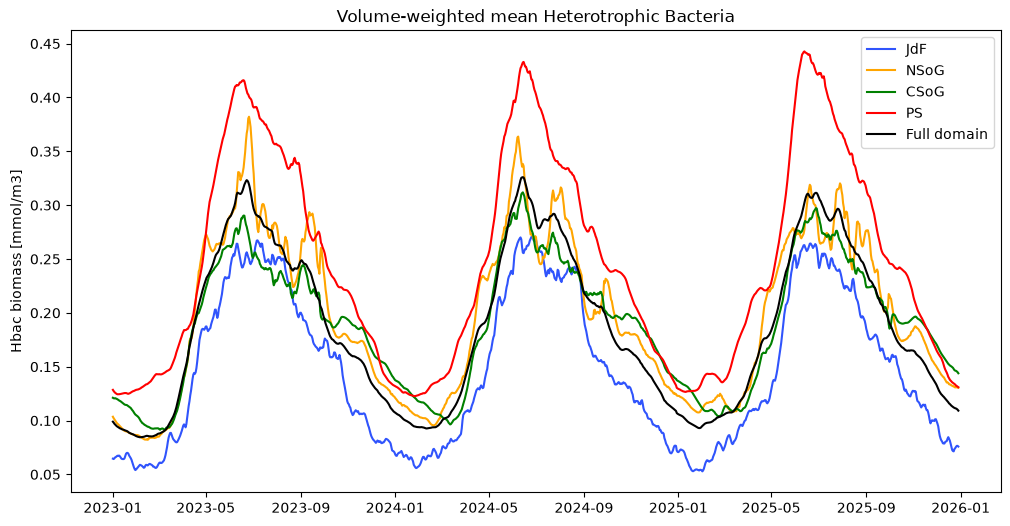

In [87]:
import pandas as pd
time = pd.date_range(start='2023-01-01',end='2025-12-29',freq='D')
plt.figure(figsize=(12,6))
for ii, region in enumerate(regions.keys()):
    plt.plot(time,weighted_means[ii,:].T,c=colors_reg[region],label=region)
plt.plot(time,weighted_means_full,c='k',label='Full domain')
plt.title('Volume-weighted mean Heterotrophic Bacteria')
plt.ylabel('Hbac biomass [mmol/m3]')
plt.legend()

In [71]:
DM = np.argmax(mean_profiles,axis=1)
DMr = np.argmax(mean_profiles_reg,axis=2)

Dmax = np.max(mean_profiles,axis=1)
Dmaxr = np.max(mean_profiles_reg,axis=2)

deptht = mask.gdept_1d[0,:]

In [72]:
dtm = np.full(DM.shape,np.nan)
dtmr = np.full(DMr.shape,np.nan)

for i in range(DM.shape[0]):
    dtm[i] = deptht[int(DM[i])]
    for j in range(DMr.shape[0]):
        dtmr[j,i] = deptht[int(DMr[j,i])]

In [124]:
def merge_consecutive(idx):
    if len(idx) == 0:
        return np.array([], dtype=int)

    # Split into consecutive groups
    groups = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)

    # Return the rounded mean of each group
    return np.array([int(np.round(g.mean())) for g in groups])

In [127]:
down

array([117, 122, 497, 868])

In [128]:
window = 4
threshold = 18

change = dtm[window:] - dtm[:-window]

up = np.where(change > threshold)[0] + window
down = np.where(change < -threshold)[0] + window

up = merge_consecutive(up)
down = merge_consecutive(down)

##manual 

down= np.array([119, 497, 868])


print(time[up])   
print(time[down])  

DatetimeIndex(['2023-03-28', '2024-03-28', '2025-04-09'], dtype='datetime64[us]', freq=None)
DatetimeIndex(['2023-04-30', '2024-05-12', '2025-05-18'], dtype='datetime64[us]', freq=None)


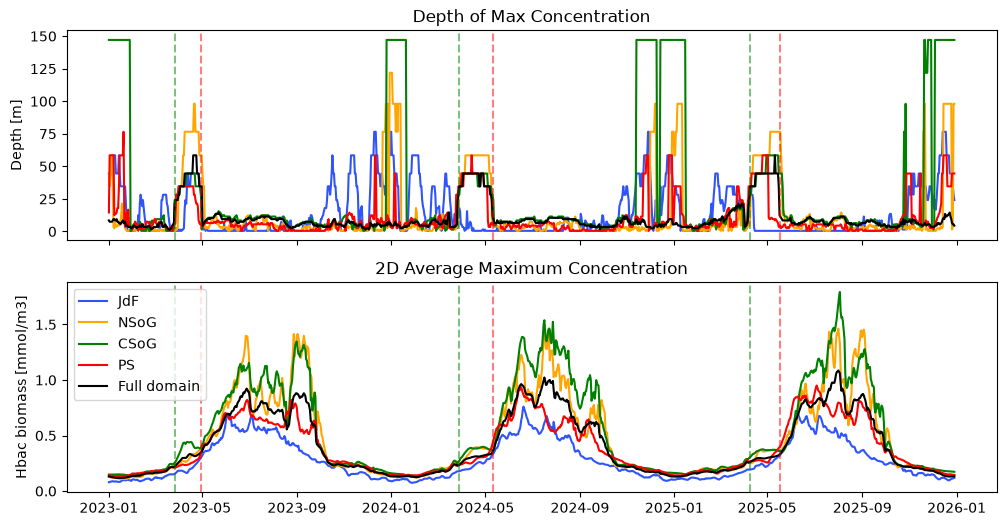

In [129]:
fig,axs = plt.subplots(2,1,figsize=(12,6),sharex=True)
for ii, region in enumerate(regions.keys()):
    axs[0].plot(time,dtmr[ii,:].T,c=colors_reg[region],label=region)
axs[0].plot(time,dtm,c='k',label='Full domain')
axs[0].set_ylabel('Depth [m]')
axs[0].set_title('Depth of Max Concentration')
for ii, region in enumerate(regions.keys()):
    axs[1].plot(time,Dmaxr[ii,:].T,c=colors_reg[region],label=region)
axs[1].plot(time,Dmax,c='k',label='Full domain')
axs[1].legend()
axs[1].set_title('2D Average Maximum Concentration')
axs[1].set_ylabel('Hbac biomass [mmol/m3]')

for i in range(len(up)):
    axs[0].axvline(time[up[i]], color='g', linestyle='--', alpha=0.5)
    axs[1].axvline(time[up[i]], color='g', linestyle='--', alpha=0.5)
for i in range(len(down)):
    axs[0].axvline(time[down[i]], color='r', linestyle='--', alpha=0.5)
    axs[1].axvline(time[down[i]], color='r', linestyle='--', alpha=0.5)


In [46]:
mean_profiles_reg = np.where(mean_profiles_reg == 0, np.nan, mean_profiles_reg)
mean_profiles = np.where(mean_profiles == 0, np.nan, mean_profiles)

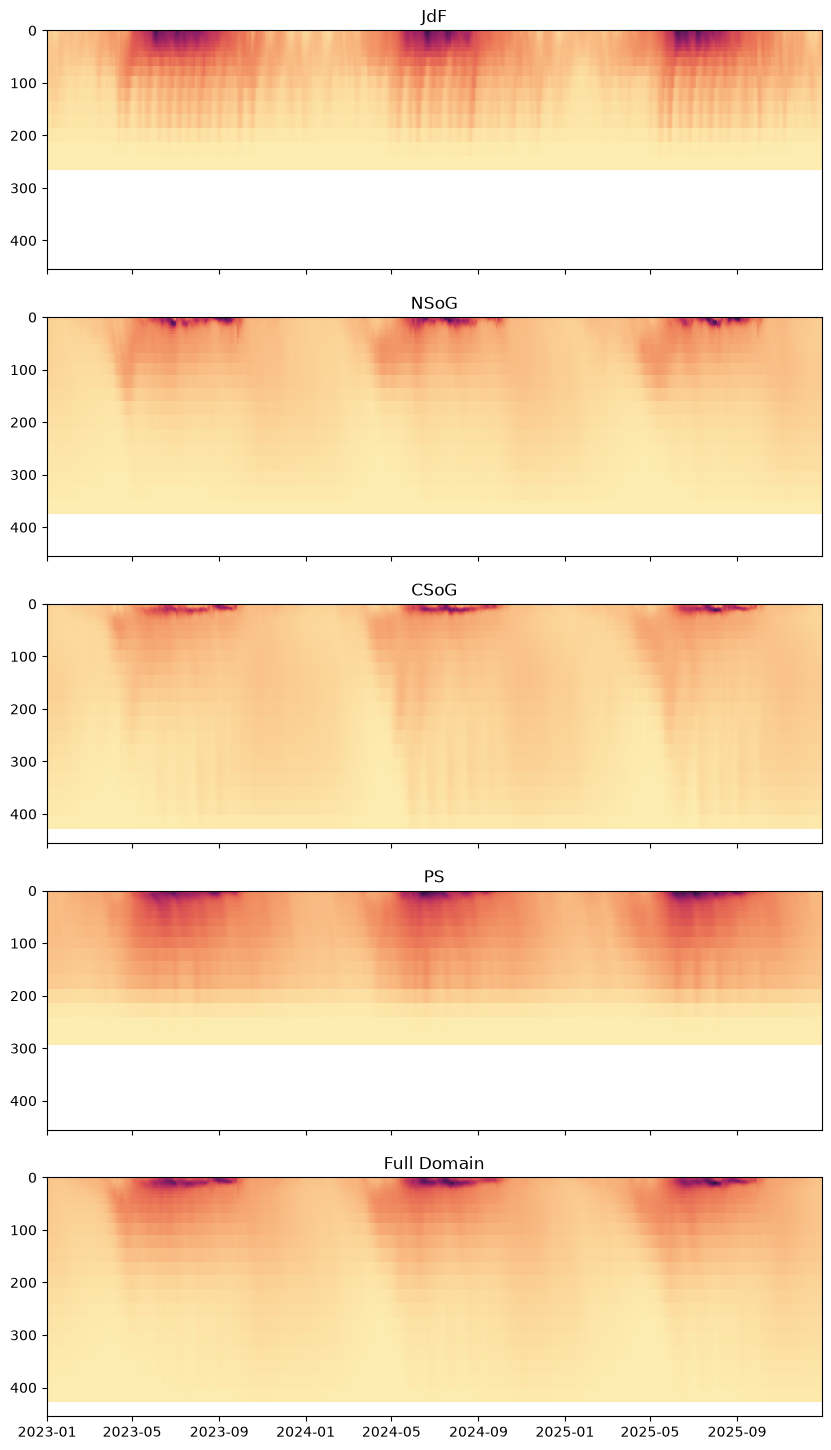

In [47]:
fig,axs = plt.subplots(5,1,figsize=(10,18),sharex=True)
time = pd.date_range(start='2023-01-01',end='2025-12-29',freq='D')
for ii, region in enumerate(regions.keys()):
    axs[ii].pcolormesh(time, mask.gdept_0[0,:,0,0],mean_profiles_reg[ii,:,:].T,cmap=cmocean.cm.matter)
    axs[ii].invert_yaxis()
    axs[ii].set_title(region)

axs[4].pcolormesh(time, mask.gdept_0[0,:,0,0], mean_profiles.T,cmap=cmocean.cm.matter)
axs[4].set_title('Full Domain')
axs[4].invert_yaxis()

/tmp/ipykernel_1931661/4080771147.py:35: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax[0].pcolormesh(xx_thal, dep_thal, var_plot, cmap=cmocean.cm.dense,vmin=0,vmax=0.4)


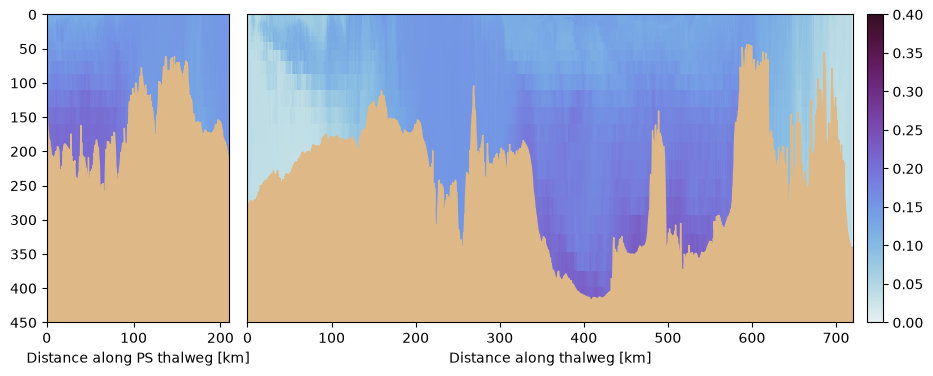

In [48]:
from salishsea_tools import visualisations as vis
import netCDF4 as nc
from matplotlib import pyplot as plt, animation, rc,colors


fig,ax=plt.subplots(1,2,figsize=(12,4),width_ratios=[0.25, 1])

fmesh = nc.Dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')
fbathy=nc.Dataset('/home/jvalenti/MOAD/grid/bathymetry_201702.nc')

clevels = np.logspace(-3,1,10)
thalweg_file = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_file2 = '/home/jvalenti/MOAD/analysis-jose/notebooks/Outfall_finalResults/mythalweg6.txt'
var = np.array(hbac[0,:,:,:])
thalweg_pts = np.loadtxt(thalweg_file, delimiter=' ', dtype=int)
thalweg_pts2 = np.loadtxt(thalweg_file2, delimiter=' ', dtype=int)
depth = fmesh.variables['gdept_0'][:]

dep_thal, distance, var_thal = vis.load_thalweg(depth[0, ...], var, fbathy['nav_lon'][:], fbathy['nav_lat'][:],thalweg_pts)
xx_thal = distance
ax[1].set_xlabel('Distance along thalweg [km]')
var_plot = vis._fill_in_bathy(var_thal, fmesh, thalweg_pts)
im = ax[1].pcolormesh(xx_thal, dep_thal, var_plot, cmap=cmocean.cm.dense,vmin=0,vmax=0.4)
#ax[1].contour(xx_thal, dep_thal, var_plot, levels=[0.1,2],colors=['White','grey'],zorder=1)

cbar = plt.colorbar(im, ax=ax[1],pad=0.02)

vis._add_bathy_patch(xx_thal, fbathy['Bathymetry'][:], thalweg_pts, ax[1], color='burlywood')
ax[1].tick_params(left = False, right = False , labelleft = False) 

dep_thal, distance, var_thal = vis.load_thalweg(depth[0, ...], var, fbathy['nav_lon'][:], fbathy['nav_lat'][:],thalweg_pts2)
xx_thal = distance
ax[0].set_xlabel('Distance along PS thalweg [km]')
var_plot = vis._fill_in_bathy(var_thal, fmesh, thalweg_pts2)
im = ax[0].pcolormesh(xx_thal, dep_thal, var_plot, cmap=cmocean.cm.dense,vmin=0,vmax=0.4)

vis._add_bathy_patch(xx_thal, fbathy['Bathymetry'][:], thalweg_pts2, ax[0], color='burlywood')

fig.subplots_adjust(wspace=0.04, hspace=0.1)
ax[1].set_ylim([450,0])
# ax[1].axvline(x=212,c='red',linestyle='--')
# ax[1].axvline(x=277.5,c='red',linestyle='--')
# ax[1].axvline(x=434.5,c='red',linestyle='--')
# ax[0].axvline(x=144,c='red',linestyle='--')

#ax[1].scatter(185,445,c='red',marker='^')
#ax[0].scatter(180,445,c='blue',marker='^')
#ax[1].axvline(x=185,c='k')
ax[0].set_ylim([450,0])
#ax[0].axvline(x=180,c='k')
ax[0].set_xlim([0,210])
#fig.savefig('thalweg.pdf')
levels = [0.1,1]
#for level, color in zip(levels, ['white', 'grey']):
 #   cbar.ax.axhline(y=level, color=color, linewidth=2)

In [49]:
vol_f = vol.fillna(0)
vol_f = vol_f.rename(z="deptht")

In [50]:
# path_run = '/ocean/atall/MOAD/Model/202410b/oxygen/'

# day = 1
# Len = 1096
# start = datetime(2023,1,1)
# make_filename(path_run,start,day, var='biol_T', res='d')
# ML = []
# Phy = []
# IN = []
# ON = []
# ZOO = []

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='d')) as ds:
#         biol = ds.isel(time_counter=0)
#         Phy.append(biol.diatoms.weighted(vol_f).sum(("deptht","y","x")) + biol.flagellates.weighted(vol_f).sum(("deptht","y","x")))
#         IN.append((biol.nitrate.weighted(vol_f).sum(("deptht","y","x"))) + (biol.ammonium.weighted(vol_f).sum(("deptht","y","x"))))
#         ON.append((biol.particulate_organic_nitrogen.weighted(vol_f).sum(("deptht","y","x"))) + (biol.dissolved_organic_nitrogen.weighted(vol_f).sum(("deptht","y","x"))))
#         ZOO.append((biol.microzooplankton.weighted(vol_f).sum(("deptht","y","x"))) + (biol.mesozooplankton.weighted(vol_f).sum(("deptht","y","x"))))

In [51]:
# IN_array = np.array(IN)
# Phy_array = np.array(Phy)
# ON_array = np.array(ON)
# ZOO_array = np.array(ZOO)

# Tot = Phy + IN + ON + ZOO

# df = pd.DataFrame({
#     "IN": IN_array,
#     "Phy": Phy_array,
#     "ON": ON_array,
#     "Zoo": ZOO_array
# }, index=pd.date_range(start='2023-01-01',end='2025-12-31',freq='D'))
# df.to_csv('biol_budget_2023-2025_202410.csv')

In [52]:
df = pd.read_csv('biol_budget_2023-2025_2.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
df_plot = df.drop(columns=["IN"])

df = pd.read_csv('biol_budget_2023-2025_202111.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
df_plot2 = df.drop(columns=["IN"])

df = pd.read_csv('biol_budget_2023-2025_202410.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
df_plot3 = df.drop(columns=["IN"])

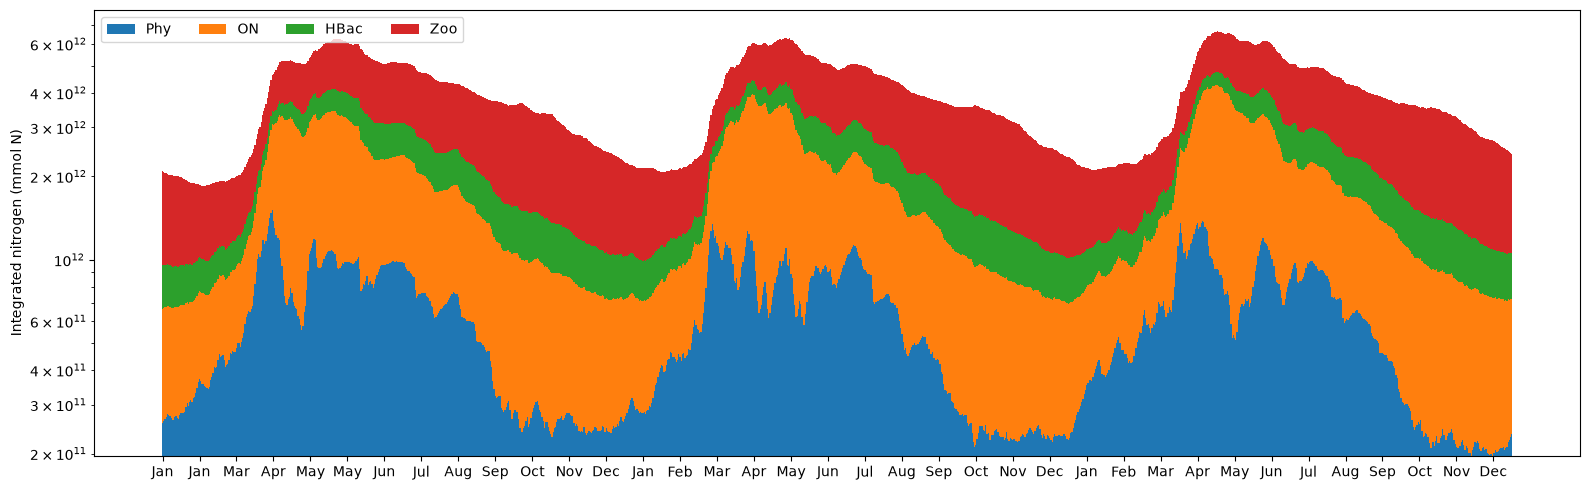

In [53]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df_plot))

for col in df_plot.columns:
    ax.bar(
        np.arange(len(df_plot)),
        df_plot[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df_plot[col].values

ax.set_yscale("log")
ax.set_ylabel("Integrated nitrogen (mmol N)")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df_plot), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df_plot.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

In [54]:
#df_plot = df_plot.drop(columns=["HBac"])
df_plot['Total'] = df_plot.sum(axis=1)
df_norm = df_plot.div(df_plot['Total'], axis=0)
df_norm = df_norm.drop(columns=["Total"])


df_plot2['Total'] = df_plot2.sum(axis=1)
df_norm2 = df_plot2.div(df_plot2['Total'], axis=0)
df_norm2 = df_norm2.drop(columns=["Total"])

df_plot3['Total'] = df_plot3.sum(axis=1)
df_norm3 = df_plot3.div(df_plot3['Total'], axis=0)
df_norm3 = df_norm3.drop(columns=["Total"])

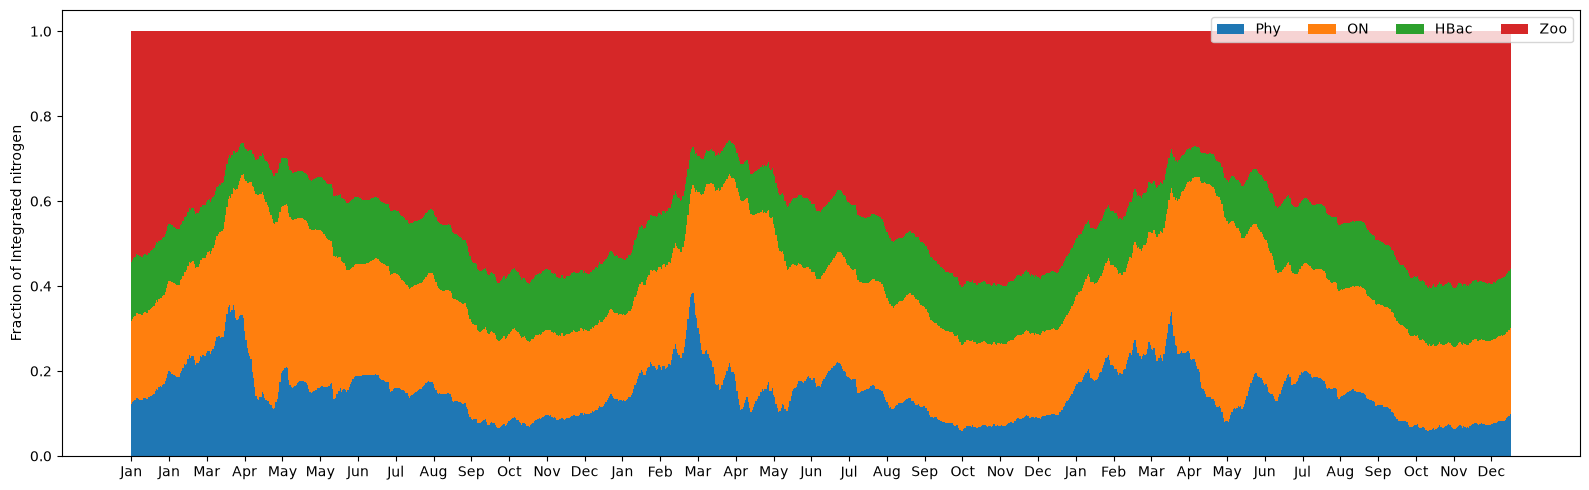

In [55]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df_norm))

for col in df_norm.columns:
    ax.bar(
        np.arange(len(df_norm)),
        df_norm[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df_norm[col].values

#ax.set_yscale("log")
ax.set_ylabel("Fraction of Integrated nitrogen")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df_norm), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df_norm.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

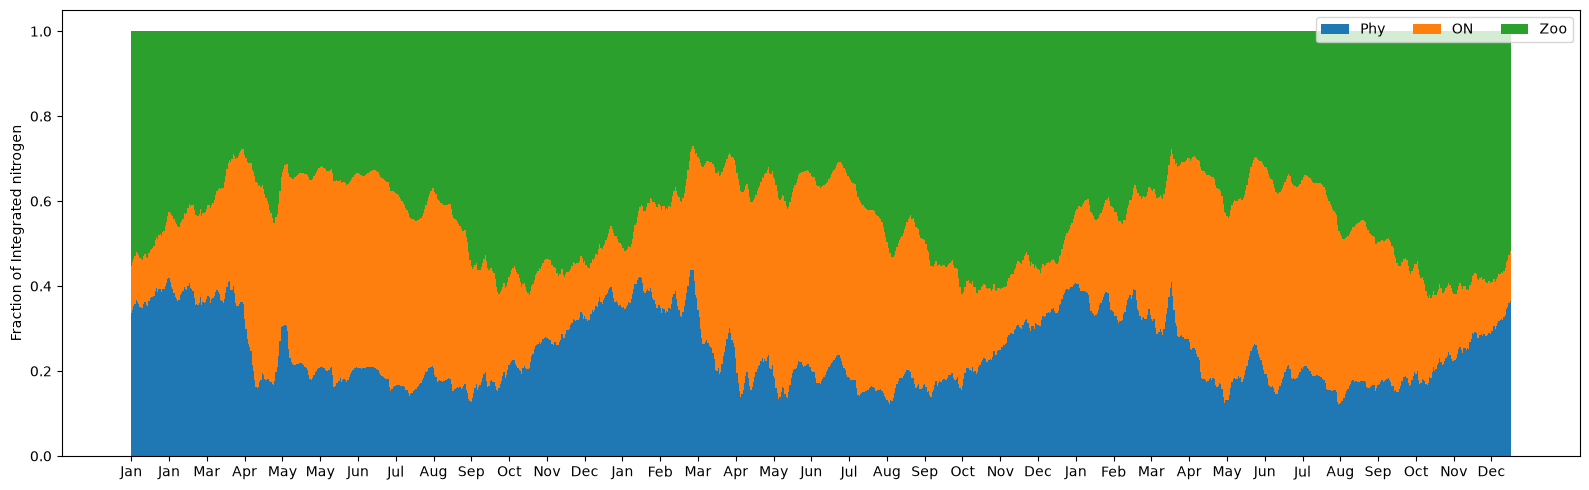

In [56]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df_norm2))

for col in df_norm2.columns:
    ax.bar(
        np.arange(len(df_norm2)),
        df_norm2[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df_norm2[col].values

#ax.set_yscale("log")
ax.set_ylabel("Fraction of Integrated nitrogen")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df_norm2), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df_norm2.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

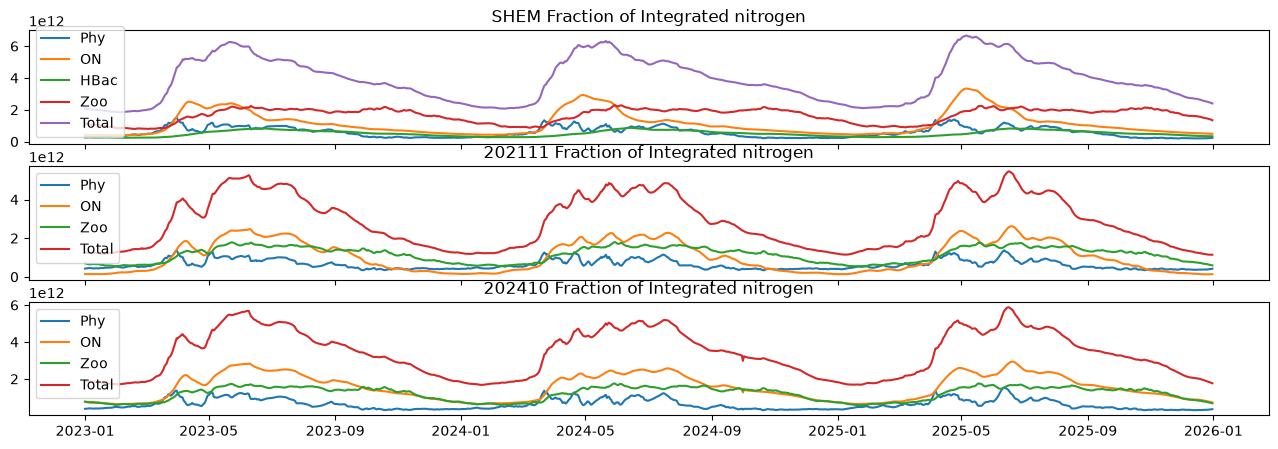

In [57]:
fig,axs = plt.subplots(3,1,figsize=(16,5),sharex=True)
axs[0].plot(df_plot.index, df_plot,label=df_plot.columns)
axs[0].set_title('SHEM Fraction of Integrated nitrogen')
axs[1].plot(df_plot2.index, df_plot2,label=df_plot2.columns)
axs[1].legend()
axs[1].set_title('202111 Fraction of Integrated nitrogen')
axs[2].plot(df_plot3.index, df_plot3,label=df_plot3.columns)
axs[2].legend()
axs[2].set_title('202410 Fraction of Integrated nitrogen')
axs[0].legend()

In [58]:
# path_run = '/data/jvalenti/results/' 

# day = 1
# Len = 1096
# start = datetime(2023,1,1)
# ML = np.full((Len), np.nan)
# Phy = np.full((Len), np.nan)

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='prod_T', res='d')) as ds:
#         biol = ds.isel(time_counter=0)
#         ML[day] = biol.HetHBAC.weighted(vol_f).sum(("deptht","y","x"))
#         Phy[day] = biol.PPDIAT.weighted(vol_f).sum(("deptht","y","x")) + biol.PPPHY.weighted(vol_f).sum(("deptht","y","x"))

In [59]:
# df = pd.DataFrame({
#     "Phy": Phy,
#     "HBac": ML,
# }, index=pd.date_range(start='2023-01-01',end='2025-12-31',freq='D'))
# df.to_csv('biol_prod_2023-2025.csv')

In [60]:
df = pd.read_csv('biol_prod_2023-2025.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")

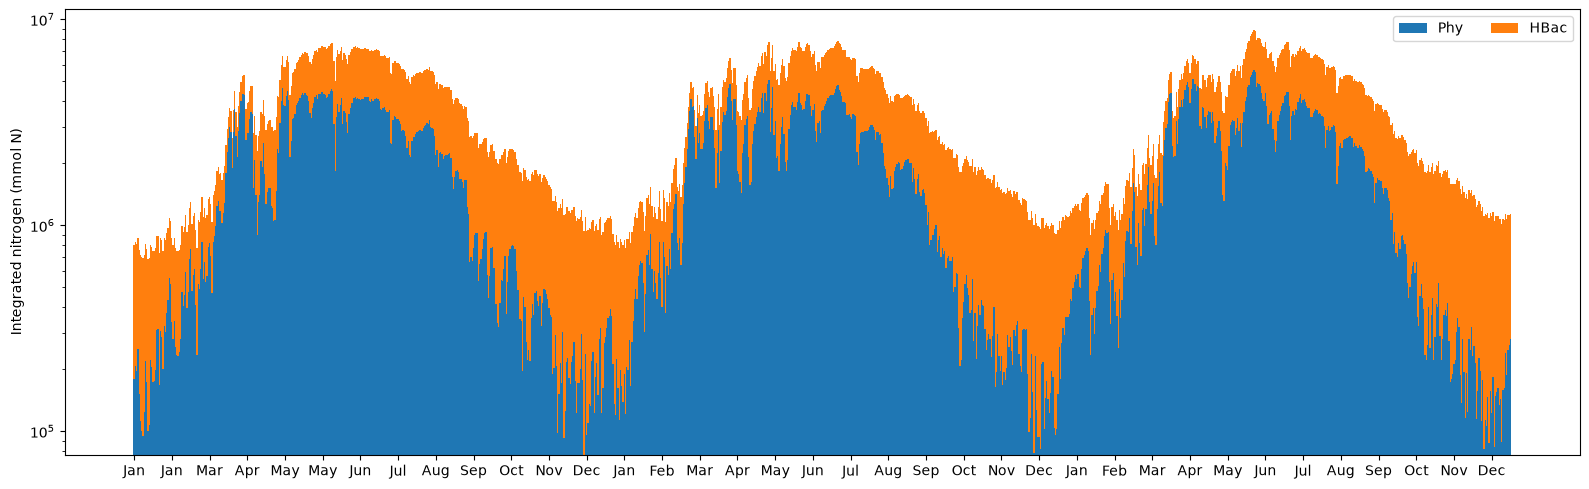

In [61]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df))

for col in df.columns:
    ax.bar(
        np.arange(len(df)),
        df[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df[col].values

ax.set_yscale("log")
ax.set_ylabel("Integrated nitrogen (mmol N)")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

In [62]:
df['Total'] = df.sum(axis=1)
df_norm = df.div(df['Total'], axis=0)
df_norm = df_norm.drop(columns=["Total"])

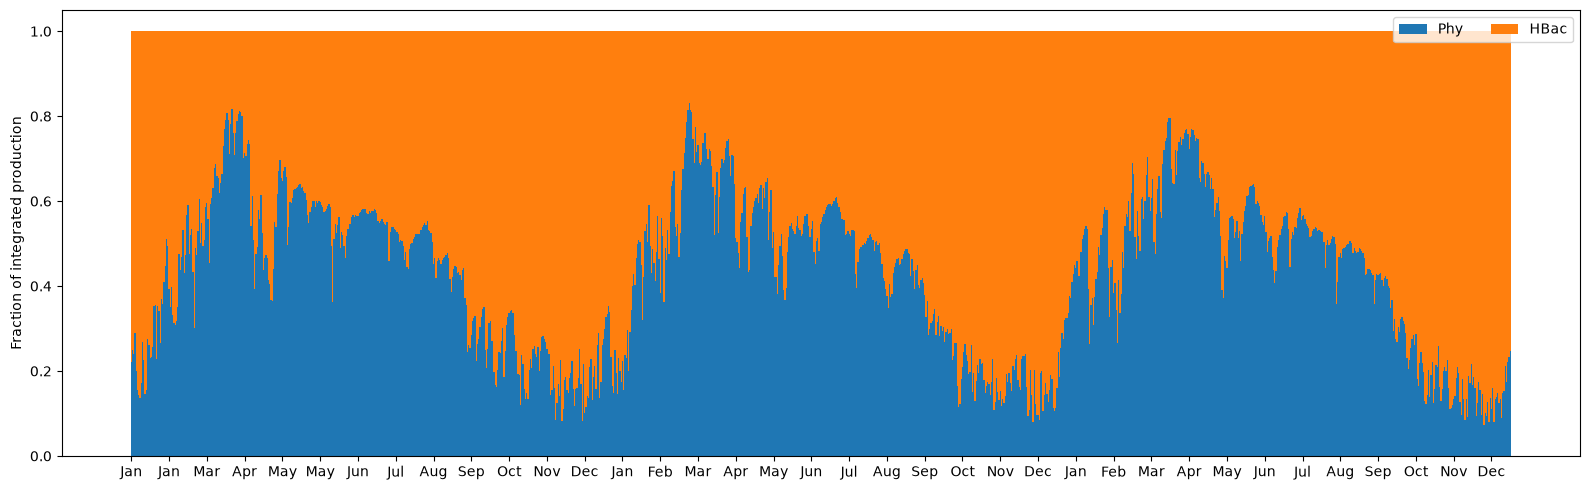

In [63]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df_norm))

for col in df_norm.columns:
    ax.bar(
        np.arange(len(df_norm)),
        df_norm[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df_norm[col].values

ax.set_ylabel("Fraction of integrated production")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df_norm), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df_norm.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

In [71]:
# path_run = '/results2/SalishSea/nowcast-green.202111/'
# Len = 1096
# start = datetime(2023,1,1)
# Z2 = np.full((Len), np.nan)
# Z1 = np.full((Len), np.nan)
# #Z1_Hbac = np.full((Len), np.nan)

# for day in progress_bar(range(Len)):
#     if day == 172:
#         continue
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='graz_T', res='d')) as ds:
#         biol = ds.isel(time_counter=0)
#         Z2[day] = biol.GRMESZDIAT.weighted(vol_f).sum(("deptht","y","x"))+biol.GRMESZPHY.weighted(vol_f).sum(("deptht","y","x")) + biol.GRMESZPON.weighted(vol_f).sum(("deptht","y","x")) + biol.GRMESZMICZ.weighted(vol_f).sum(("deptht","y","x"))
#         Z1[day] = biol.GRMICZDIAT.weighted(vol_f).sum(("deptht","y","x")) + biol.GRMICZPHY.weighted(vol_f).sum(("deptht","y","x")) + biol.GRMICZPON.weighted(vol_f).sum(("deptht","y","x")) + biol.GRMICZMICZ.weighted(vol_f).sum(("deptht","y","x"))
#         #Z1_Hbac[day] = biol.GRMICZHBAC.weighted(vol_f).sum(("deptht","y","x"))

In [70]:
# df = pd.DataFrame({
#     "Z2": Z2,
#     "Z1": Z1
#   #  "Z1_Hbac": Z1_Hbac
# }, index=pd.date_range(start='2023-01-01',end='2025-12-31',freq='D'))
# df.to_csv('biol_graz_2023-2025_202111.csv')

In [76]:
df = pd.read_csv('biol_graz_2023-2025.csv', index_col=0, parse_dates=True)
df.index = pd.DatetimeIndex(df.index, freq="D")
#df = df.drop(columns=["Z1_Hbac"])
df['Total'] = df.sum(axis=1)
df_norm = df.div(df['Total'], axis=0)
df_norm = df_norm.drop(columns=["Total"])
df = df.drop(columns=["Total"])


df2 = pd.read_csv('biol_graz_2023-2025_202111.csv', index_col=0, parse_dates=True)
df2.index = pd.DatetimeIndex(df2.index, freq="D")
df2['Total'] = df2.sum(axis=1)
df_norm2 = df2.div(df2['Total'], axis=0)
df_norm2 = df_norm2.drop(columns=["Total"])
df2 = df2.drop(columns=["Total"])


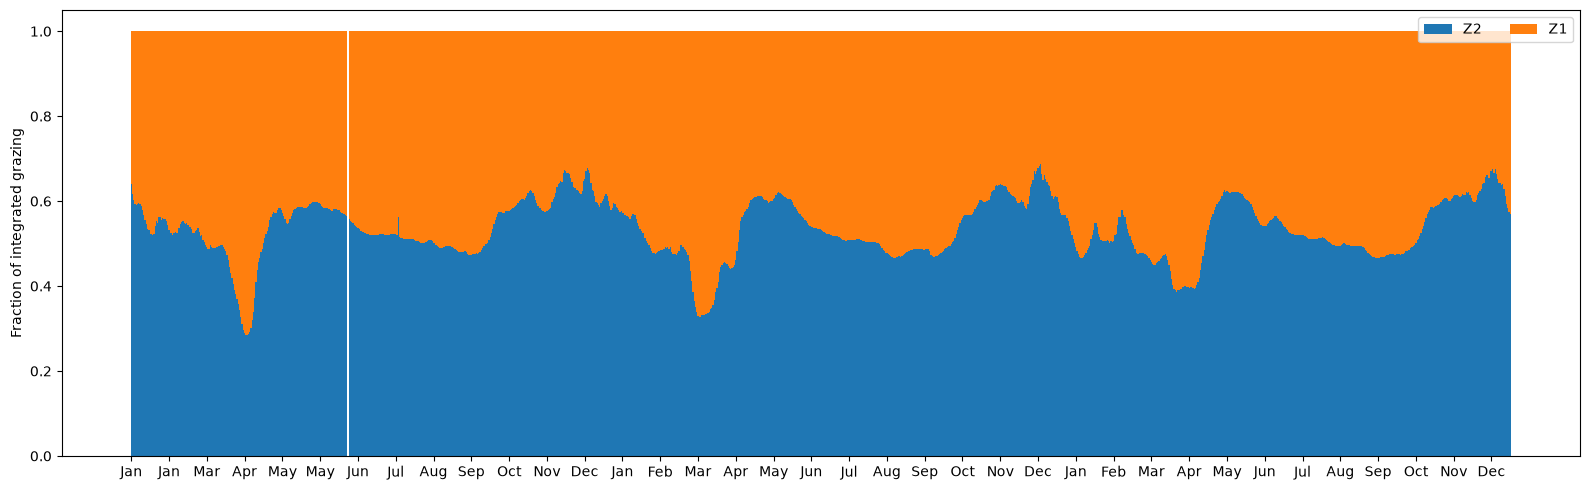

In [67]:
fig, ax = plt.subplots(figsize=(16,5))

bottom = np.zeros(len(df_norm))

for col in df_norm.columns:
    ax.bar(
        np.arange(len(df_norm)),
        df_norm[col],
        bottom=bottom,
        width=1.0,
        label=col
    )
    bottom += df_norm[col].values

ax.set_ylabel("Fraction of integrated grazing")
ax.set_xlabel("")

# monthly ticks
ticks = np.arange(0, len(df_norm), 30)
ax.set_xticks(ticks)
ax.set_xticklabels(
    df_norm.index.strftime("%b").values[ticks],
    rotation=0
)

ax.legend(ncol=5)
plt.tight_layout()

In [81]:
df['Z1_tot'] = df['Z1'] + df['Z1_Hbac']
df = df.drop(columns=["Z1_Hbac"])
df = df.drop(columns=["Z1"])


Text(0.5, 1.0, 'SHEM vs 202111 Fraction of Integrated grazing')

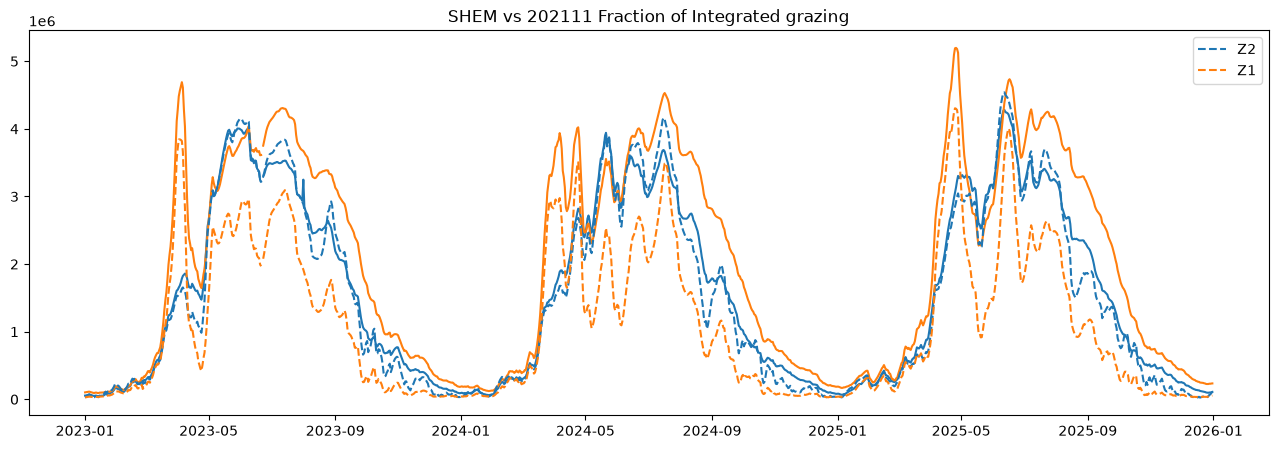

In [90]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig,axs = plt.subplots(1,figsize=(16,5),sharex=True)
for i,col in enumerate(df.columns):
    axs.plot(df.index, df[col],color = colors[i])
#axs[0].plot(df.index, df,label=df.columns)
axs.set_title('SHEM Fraction of Integrated grazing')
for i,col in enumerate(df2.columns):
    axs.plot(df2.index, df2[col],label=col,color = colors[i],linestyle='--')
axs.legend()
axs.set_title('SHEM vs 202111 Fraction of Integrated grazing')